# EDA Machine Learning
### Mujica Camilo
### 2026-03-09
## ANALISIS EXPLORATORIO DE DATOS

En el presente documento se realiza un análisis del conjunto de datos obtenido de la base World Bank, específicamente de la fuente Health Nutrition and Population Statistics, disponible en el siguiente enlace: https://databank.worldbank.org/source/health-nutrition-and-population-statistics

Este dataset recopila información sobre indicadores de salud, nutrición y población para más de 266 territorios a nivel mundial. Entre estos territorios se incluyen principalmente países, pero también agregaciones regionales que agrupan varios países, así como conjuntos de islas y otras divisiones geográficas.

Cada territorio cuenta con múltiples indicadores asociados. Entre ellos se encuentran, por ejemplo: la tasa de fecundidad adolescente (nacimientos por cada 1.000 mujeres entre 15 y 19 años), la cantidad de adultos (15 años o más) y niños (0 a 14 años) que viven con VIH, la edad al primer matrimonio en mujeres y hombres, entre muchos otros. En total, el dataset contiene 474 indicadores distintos.

La estructura del archivo incluye columnas correspondientes al nombre del indicador, código del indicador, nombre del país, código del país y valores anuales comprendidos entre 1960 y 2024.

## Objetivo 
En este EDA se analizarán la información recolectada entre 1960 y 2024 sobre la fertilidad adolescente en colombia, se busca concluir que tipo de compórtamiento ha tenido este indicador, y cuál podría ser su comportamiento en un lapso de 5 años en el futuro.
## Cargue de las librerías

In [187]:
#Importamos las librerias
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from statsmodels.tsa.arima.model import ARIMA

## Cargue del DataSet

In [127]:
#Cargamos el data set
df = pd.read_csv(r"C:\py proyectos\EDA Vizdata\a6229004-b9bf-4015-9569-b0b826d6db87_Data.csv")
# Eliminamos las últimas 5 filas que no necesitamos porque son la fuente y la fecha de actualización 
df = df.iloc[0:474, 0:69]
print("Dataset cargado con éxito. Dimensiones:", df.shape)

Dataset cargado con éxito. Dimensiones: (474, 69)


In [128]:
df.head(n=3)

,Series Name,Series Code,Country Name,Country Code,1960 [YR1960],1961 [YR1961],1962 [YR1962],1963 [YR1963],1964 [YR1964],1965 [YR1965],...,2015 [YR2015],2016 [YR2016],2017 [YR2017],2018 [YR2018],2019 [YR2019],2020 [YR2020],2021 [YR2021],2022 [YR2022],2023 [YR2023],2024 [YR2024]
0,"Adolescent fertility rate (births per 1,000 wo...",SP.ADO.TFRT,Colombia,COL,115.373,113.802,112.147,110.377,107.885,104.921,...,69.785,66.84,65.985,65.17,64.278,62.885,62.023,60.175,59.473,..
1,Adults (ages 15+) and children (0-14 years) li...,SH.HIV.TOTL,Colombia,COL,..,..,..,..,..,..,...,160000,170000,170000,180000,190000,200000,210000,220000,230000,230000
2,Adults (ages 15+) and children (ages 0-14) new...,SH.HIV.INCD.TL,Colombia,COL,..,..,..,..,..,..,...,11000,11000,12000,12000,12000,12000,12000,13000,12000,..


# Dimensión de nuestro dataset
El resultado indica que el conjunto de datos posee:

- 474 filas

- 69 columnas

El DataSet cuenta con 474 filas, que representan los 474 indicadores y 69 columnas, de las cuales las cuatro primeras son Series Name, Series Code, Country Name y Country Code, las 65 restantes son los años de 1960 a 2024 

# Set de datos 
La información recolectada se encuentra almacenada en un archivo en formato CSV, el cual contiene 479 filas y 69 columnas. Cada registro corresponde a un indicador específico de salud, nutrición o población asociado a un país o territorio determinado. Es decir, cada fila representa la combinación de un indicador y un territorio, mientras que las columnas contienen información descriptiva y valores anuales del indicador. Las columnas son:

1. Series Name: Contiene el nombre del indicador de salud o población (por ejemplo, tasa de fecundidad, esperanza de vida, prevalencia de VIH, entre otros) (Categórica)

2. Series Code: Código único asignado por el Banco Mundial para identificar cada indicador. (Categórica)

3. Country Name: : Nombre del país o territorio al que pertenecen los datos.(Categórica)

4. Country Code: Código estandarizado del país según la clasificación internacional.(Categórica)

5. Variables temporales(1960-2024): Cada una de estas columnas contiene el valor cuantitativo del indicador correspondiente para un año específico. (Numéricas)

# Transformación del dataset
El formato ancho dificulta la manipulación, visualización y análisis de series temporales, por lo que se realizó una transformación a formato largo siguiendo el principio de Tidy Data.

In [129]:
#Hacemos una lista de las columnas que no son años
id_vars = ['Series Name', 'Series Code', 'Country Name', 'Country Code']

#Hacemos una lista con las columnas que sí son años
year_cols = [col for col in df.columns if col not in id_vars]

# Transformar de formato ancho (Wide) a largo (Long)
df_long = pd.melt(df, 
                  id_vars=id_vars, 
                  value_vars=year_cols, 
                  var_name='Year', 
                  value_name='Value')
# Limpieza de cadenas y tipos de datos
# 1. Limpiar el nombre del año (ej: de '1960 [YR1960]' a '1960')

df_long['Year'] = df_long['Year'].str.extract('^(\d{4})').astype(int)


# 2. Manejar valores nulos (en el original vienen como "..")
df_long['Value'] = df_long['Value'].replace('..', np.nan)
df_long['Value'] = pd.to_numeric(df_long['Value'])

# 3. Nos quedamos solo con los valores de "Adolescent fertility rate (births per 1,000 women ages 15-19)"
df_long = df_long[df_long['Series Name'] == "Adolescent fertility rate (births per 1,000 women ages 15-19)"]
df_long.head()

,Series Name,Series Code,Country Name,Country Code,Year,Value
0,"Adolescent fertility rate (births per 1,000 wo...",SP.ADO.TFRT,Colombia,COL,1960,115.373
474,"Adolescent fertility rate (births per 1,000 wo...",SP.ADO.TFRT,Colombia,COL,1961,113.802
948,"Adolescent fertility rate (births per 1,000 wo...",SP.ADO.TFRT,Colombia,COL,1962,112.147
1422,"Adolescent fertility rate (births per 1,000 wo...",SP.ADO.TFRT,Colombia,COL,1963,110.377
1896,"Adolescent fertility rate (births per 1,000 wo...",SP.ADO.TFRT,Colombia,COL,1964,107.885


Con esta transformación obtenemos una nueva columna 'Value' la cual representa el valor que tuvo el respectivo indicador en el año que se muetra en la columna 'Year'
## Limpieza del DataSet
Puesto que el presente análisis se enfoca exclusivamente en el inidcador de "Adolescent fertility rate (births per 1,000 women ages 15-19)" para el país de Colombia podemos conservar solo las columnas de value y year, esto para as+i tener un DataSet más limpio y sin columnas que no son necesarias para el análisis. Por lo tanto, se procede a eliminar el resto de columnas.

In [130]:
# 4. Eliminar columnas redundantes para el análisis de Colombia (como en el link)
df_long = df_long.drop(columns=['Country Name', 'Country Code','Series Name','Series Code'])


Así, el DataSet con el que trabajaríamos se vería de esta forma:

In [131]:
# Renombramos en minúscalas los nombres de las columnas por comodidad 
df_long.rename(columns={'Year':'year','Value':'value'}, inplace=True)
df_long

,year,value
0,1960,115.373
474,1961,113.802
948,1962,112.147
1422,1963,110.377
1896,1964,107.885
...,...,...
28440,2020,62.885
28914,2021,62.023
29388,2022,60.175
29862,2023,59.473


# Análisis del indicador.
Analicemos las carateristicas generales de los datos del indicador.

In [132]:
df_long.isna().sum()

year     0
value    1
dtype: int64

Vemos que Value tiene un dato faltante, busquemos en cual año es.

In [133]:
df_long[df_long['value'].isna()]

,year,value
30336,2024,NaN


Vemos que es en el año 2024, podemos eliminar esta fila del df_long, y trabajar con los años entre 1960 hasta 2023.

In [134]:
df_long = df_long.dropna(axis=0)
df_long

,year,value
0,1960,115.373
474,1961,113.802
948,1962,112.147
1422,1963,110.377
1896,1964,107.885
...,...,...
27966,2019,64.278
28440,2020,62.885
28914,2021,62.023
29388,2022,60.175


Observemos un histograma con los valores del indicador.

c:\Users\Usuario\miniconda3\envs\vizdata_env\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\Usuario\miniconda3\envs\vizdata_env\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


Text(0.5, 1.0, 'Histograma de los valores del indicador')

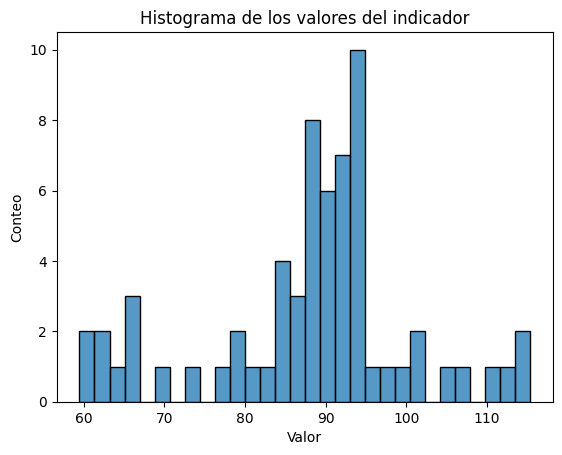

In [201]:
sns.histplot(df_long["value"], bins=30)
plt.xlabel('Valor')
plt.ylabel('Conteo')
plt.title('Histograma de los valores del indicador')

La distribución muestra que la mayor parte de los años presentan valores cercanos al rango medio (85–95), pero existen valores extremos que evidencian cambios importantes en el comportamiento de la fertilidad adolescente a lo largo del tiempo, reflejando transformaciones sociales y demográficas en Colombia.

La distribución no parece perfectamente simétrica. Se aprecia cierta dispersión hacia valores altos y bajos, lo que refleja que el indicador ha experimentado cambios importantes a lo largo del tiempo en lugar de mantenerse constante.

La amplitud aproximada del histograma (entre 60 y 115) muestra que la tasa ha tenido una variación considerable a lo largo de las décadas, lo que sugiere cambios demográficos y sociales importantes, posiblemente relacionados con factores como:

- Mayor acceso a educación sexual

- Disponibilidad de métodos anticonceptivos

- Cambios en políticas públicas de salud reproductiva
 
- Transformaciones socioculturales en el país.

# Análisis del indicador a lo largo del tiempo

In [ ]:
y = df_long["value"].values
x = df_long["year"].values

# primera derivada
dy = np.diff(y)

# cambio de signo en la derivada
sign_change = np.where(np.diff(np.sign(dy)) != 0)[0] + 1

change_points = df_long.iloc[sign_change]

change_years =change_points['year'].values

final_change_years = change_years
# Conservamos solo los años cuyo cambio de pendiente dura al menos 3 años 
for i in range(len(change_years)-1):
    if change_years[i] > (change_years[i+1] - 3):
        indices = np.where(final_change_years == change_years[i])
        final_change_years = np.delete(final_change_years, indices)

change_points = change_points[change_points['year'].isin(final_change_years)]
change_points

1976


,year,value
9480,1980,89.077
11376,1984,83.074
15168,1992,94.616
17538,1997,91.732
18960,2000,94.496
24648,2012,79.556


c:\Users\Usuario\miniconda3\envs\vizdata_env\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\Usuario\miniconda3\envs\vizdata_env\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\Usuario\miniconda3\envs\vizdata_env\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\Usuario\miniconda3\envs\vizdata_env\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in 

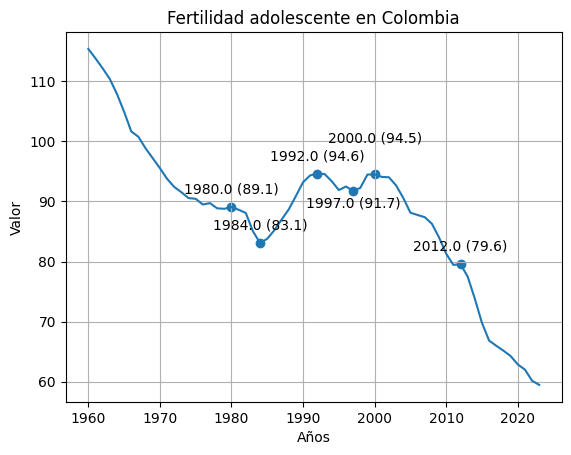

In [185]:
# Analicemos cuantos datos tenemos por indicador
sns.lineplot(df_long, x='year', y='value')
plt.xlabel('Años')
plt.ylabel('Valor')
plt.title('Fertilidad adolescente en Colombia')
plt.grid()
plt.scatter(x=change_points['year'],y=change_points['value'])
for _, row in change_points.iterrows():
    if row['year'] == 1997:
        plt.annotate(
            f"{row['year']} ({row['value']:.1f})",
            (row["year"], row["value"]-5),
            xytext=(0,10),
            textcoords="offset points",
            ha="center"
        )
    elif row['year'] == 2000:
            plt.annotate(
            f"{row['year']} ({row['value']:.1f})",
            (row["year"], row["value"]+3),
            xytext=(0,10),
            textcoords="offset points",
            ha="center"
        )
    else:
         plt.annotate(
            f"{row['year']} ({row['value']:.1f})",
            (row["year"], row["value"]),
            xytext=(0,10),
            textcoords="offset points",
            ha="center"
         )

Se puede ver como el índice de fertilidad adolescente ha tenido un comportamiento descendente en general, pero con una subida a partir de 1984, hasta un pico de 95.6 en 1992 y cierta estabilidad hasta que en el 2000 después de tener un índice de 94.5 comenzó a bajar, llegando a estar debajo de 60 en 2023. 

## Predicción para los próximos 10 años

Con esta información, y viendo el comportamiento descendente del indicador en los últimos 20 años, podemos entrenar el modelo Autoregressive Integrated Moving Average (media móvil integrada autorregresiva) o por su sigla ARIMA, para predecir como podrían ser los valores de este indicador para los próximos 10 años.
### Ajuste del modelo

In [190]:
years = df_long["year"].values
values = df_long["value"].values
model = ARIMA(values, order=(1,1,1))
model_fit = model.fit()

# predecir 10 años al futuro
steps = 10
forecast = model_fit.forecast(steps=steps)

future_years = np.arange(df_long["year"].max()+1, df_long["year"].max()+1+steps)

### Visualización de las predicciones

c:\Users\Usuario\miniconda3\envs\vizdata_env\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\Usuario\miniconda3\envs\vizdata_env\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\Usuario\miniconda3\envs\vizdata_env\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\Usuario\miniconda3\envs\vizdata_env\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in 

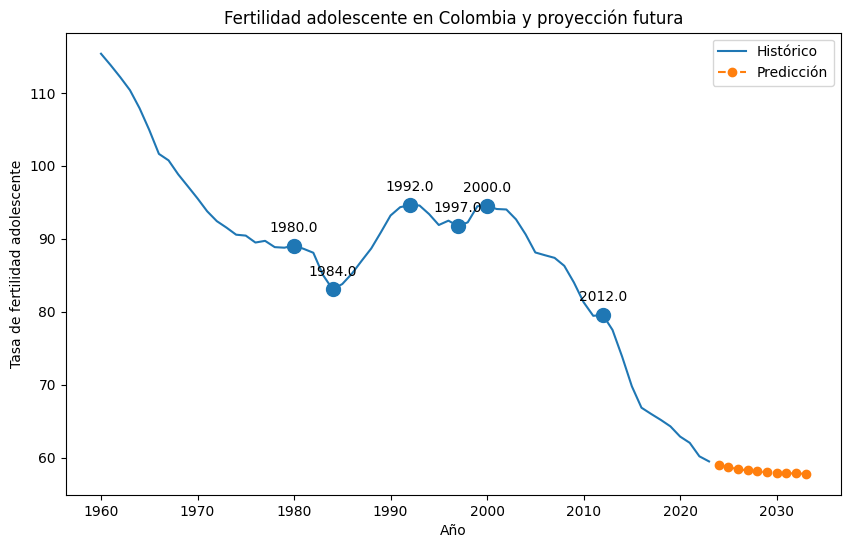

,0
2024,59.014108
2025,58.673930
2026,58.421755
2027,58.234816
2028,58.096239
2029,57.993510
2030,57.917358
2031,57.860905
2032,57.819057
2033,57.788035


In [198]:
plt.figure(figsize=(10,6))

# serie original
sns.lineplot(data=df_long, x="year", y="value", label="Histórico")

# puntos de cambio
plt.scatter(change_points["year"], change_points["value"], s=100)

for _, row in change_points.iterrows():
    plt.annotate(
        f"{row['year']}",
        (row["year"], row["value"]),
        xytext=(0,10),
        textcoords="offset points",
        ha="center"
    )

plt.plot(future_years, forecast, linestyle="--", marker="o", label="Predicción")

plt.title("Fertilidad adolescente en Colombia y proyección futura")
plt.xlabel("Año")
plt.ylabel("Tasa de fertilidad adolescente")

plt.legend()

plt.show()
predicciones = pd.DataFrame(forecast,future_years)
predicciones

Se puede ver como en las predicciones el índice va bajando hasta situarce en 57.78 para el año 2033.

El modelo ARIMA proyecta que, si la tendencia reciente continúa, la tasa de fertilidad adolescente en Colombia podría seguir disminuyendo en los próximos años. Sin embargo, estas predicciones deben interpretarse con cautela, ya que el comportamiento del indicador depende de factores sociales, económicos y políticas públicas.